In [3]:
##  importing packages relevant to this project

import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

## reading the csv file to understand the variables and how the data is formatted.

WorldHappiness = pd.read_csv('WorldHappinessReport.csv')
WorldHappiness.head(20)

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
0,2011,1,Denmark,7.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,2,Finland,7.579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,3,Norway,7.524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,4,Netherlands,7.512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,5,Canada,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2011,6,Switzerland,7.499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2011,7,Sweden,7.379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2011,8,New Zealand,7.372,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2011,9,Australia,7.345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2011,10,Ireland,7.284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
## further information which could help me further understand what is in the data

WorldHappiness.info()
WorldHappiness.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               1018 non-null   float

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465655,5.436091,5.664733,1.265670,1.096746,0.553435,0.609465,0.147343,0.144911,1.736935
std,4.249844,43.845101,1.123870,1.140959,1.107424,0.463823,0.357642,0.229980,0.212070,0.084335,0.118803,0.657497
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619707,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063156,1.305000
50%,2018.000000,76.000000,5.480000,5.592631,5.812000,1.304000,1.140119,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290110,6.486500,1.636000,1.382000,0.712325,0.735000,0.195477,0.181330,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.569814,0.587000,3.482000


In [5]:
## looking for missing values

WorldHappiness.isnull().sum()

year                                    0
rank_in_year                            0
country                                 0
happiness_score                         0
lower_whisker                        1094
upper_whisker                        1094
explained_log_gdp_per_capita         1097
explained_social_support             1097
explained_healthy_life_expectancy    1100
explained_freedom                    1099
explained_generosity                 1097
explained_corruption                 1098
dystopia_plus_residual               1103
dtype: int64

In [6]:
## create a copy to avoid editing the raw data csv file.

WorldHappinessCopy = WorldHappiness.copy()
WorldHappinessCopy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               2116 non-null   int64  
 1   rank_in_year                       2116 non-null   int64  
 2   country                            2116 non-null   object 
 3   happiness_score                    2116 non-null   float64
 4   lower_whisker                      1022 non-null   float64
 5   upper_whisker                      1022 non-null   float64
 6   explained_log_gdp_per_capita       1019 non-null   float64
 7   explained_social_support           1019 non-null   float64
 8   explained_healthy_life_expectancy  1016 non-null   float64
 9   explained_freedom                  1017 non-null   float64
 10  explained_generosity               1019 non-null   float64
 11  explained_corruption               1018 non-null   float

In [7]:
## Focusing on data post 2019 where variables other than happiness_score were measured

WorldHappinessLast1021 = WorldHappinessCopy.iloc[-1021:]
WorldHappinessLast1021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 1095 to 2115
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   year                               1021 non-null   int64  
 1   rank_in_year                       1021 non-null   int64  
 2   country                            1021 non-null   object 
 3   happiness_score                    1021 non-null   float64
 4   lower_whisker                      1021 non-null   float64
 5   upper_whisker                      1021 non-null   float64
 6   explained_log_gdp_per_capita       1018 non-null   float64
 7   explained_social_support           1018 non-null   float64
 8   explained_healthy_life_expectancy  1015 non-null   float64
 9   explained_freedom                  1016 non-null   float64
 10  explained_generosity               1018 non-null   float64
 11  explained_corruption               1017 non-null   fl

In [8]:
## understanding the top 25 ranked happiness countries

WorldHappinessLast1021.head(25)

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
1095,2019,2,Denmark,7.6456,7.579955,7.711245,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260,2.432741
1096,2019,3,Switzerland,7.5599,7.491272,7.628528,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946,2.350267
1097,2019,4,Iceland,7.5045,7.387653,7.621347,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541,2.460688
1098,2019,5,Norway,7.4880,7.419719,7.556281,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101,2.168266
1099,2019,6,Netherlands,7.4489,7.394428,7.503372,1.338946,1.463646,0.975675,0.613626,0.336318,0.368570,2.352117
1100,2019,7,Sweden,7.3535,7.282481,7.424519,1.322235,1.433348,0.986470,0.650298,0.272828,0.442066,2.246299
1101,2019,8,New Zealand,7.2996,7.222248,7.376953,1.242318,1.487218,1.008138,0.646790,0.325726,0.461268,2.128108
1102,2019,9,Austria,7.2942,7.228804,7.359596,1.317286,1.437445,1.000934,0.603369,0.255510,0.281256,2.398446
1103,2019,10,Luxembourg,7.2375,7.177031,7.297970,1.536676,1.387528,0.986443,0.610137,0.195954,0.367041,2.153700
1104,2019,11,Canada,7.2321,7.152905,7.311295,1.301648,1.435392,1.022502,0.644028,0.281529,0.351702,2.195269


In [9]:
## understanding the bottom 25 ranked happiness countries

WorldHappinessLast1021.tail(25)

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
2091,2025,123,Burkina Faso,4.455,4.354,4.557,0.995,0.630,0.343,0.820,0.135,0.253,1.280
2092,2025,124,Benin,4.393,4.262,4.525,1.122,0.087,0.409,0.816,0.086,0.243,1.630
2093,2025,125,Chad,4.385,4.252,4.518,0.979,0.676,0.292,0.571,0.151,0.116,1.600
2094,2025,126,Lesotho,4.375,4.170,4.579,1.007,1.135,0.000,0.741,0.057,0.069,1.365
2095,2025,127,Bangladesh,4.319,4.197,4.442,1.353,0.245,0.672,1.078,0.111,0.087,0.774
2096,2025,128,Gambia,4.306,4.210,4.403,1.050,0.853,0.393,0.807,0.223,0.042,0.938
2097,2025,129,Myanmar,4.287,4.144,4.430,1.211,0.977,0.488,0.722,0.292,0.160,0.436
2098,2025,130,Liberia,4.280,4.116,4.444,0.867,0.815,0.386,0.796,0.125,0.066,1.225
2099,2025,131,Togo,4.277,4.170,4.384,1.039,0.572,0.442,0.682,0.085,0.144,1.314
2100,2025,132,Madagascar,4.174,4.062,4.287,0.867,0.710,0.393,0.380,0.118,0.116,1.590


In [10]:
## values sorted by explained_log_gdp_per_capita

WorldHappinessLast1021.sort_values(by = 'explained_log_gdp_per_capita', ascending = False)

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
1401,2021,6,Luxembourg,7.404,7.307,7.501,2.209,1.155,0.790,0.700,0.120,0.388,2.042
1550,2022,9,Luxembourg,7.228,7.093,7.363,2.200,1.357,0.549,0.710,0.149,0.418,1.845
1566,2022,25,Singapore,6.587,6.454,6.720,2.168,1.354,0.607,0.660,0.170,0.561,1.067
2004,2025,36,Singapore,6.585,6.497,6.674,2.167,1.471,1.059,0.980,0.145,0.512,0.252
1977,2025,9,Luxembourg,7.063,6.971,7.154,2.162,1.465,0.981,1.056,0.111,0.382,0.907
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,2022,88,Venezuela,5.211,5.085,5.336,0.000,1.257,0.341,0.369,0.205,0.084,2.955
1903,2024,82,Venezuela,5.683,5.570,5.796,0.000,1.493,0.515,0.702,0.154,0.117,2.701
1740,2023,62,Bahrain,5.959,5.766,6.153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1766,2023,88,Tajikistan,5.281,5.201,5.361,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
## grouping the data by countries to understand mean values

WorldHappinessGrouped = WorldHappinessLast1021.groupby('country').agg('mean')
WorldHappinessGrouped

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,,
Afghanistan,2022.0,146.000000,1.983414,1.914933,2.051753,0.610244,0.050919,0.191579,0.000000,0.097748,0.061318,0.971462
Albania,2022.0,90.428571,5.264671,5.141816,5.387812,1.320379,0.861212,0.686761,0.651135,0.136718,0.040052,1.568271
Algeria,2022.0,91.142857,5.284586,5.177914,5.391400,1.254265,1.143572,0.666203,0.328992,0.092416,0.154742,1.644402
Argentina,2022.0,50.714286,6.129957,6.020279,6.239492,1.448352,1.337506,0.624253,0.668834,0.070729,0.076202,1.903792
Armenia,2022.0,88.714286,5.319114,5.206708,5.430949,1.306752,1.067797,0.707551,0.625297,0.057461,0.165088,1.388595
...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,2022.0,91.857143,5.303886,5.183459,5.424313,0.231748,1.231364,0.546718,0.467674,0.160168,0.091089,2.574977
Viet Nam,2022.0,64.142857,5.833643,5.752036,5.915536,1.179299,1.206439,0.613591,0.825691,0.101356,0.135550,1.771854
Yemen,2022.0,139.000000,3.672733,3.512375,3.832925,0.567784,1.184413,0.361667,0.366620,0.084448,0.100392,1.006912


In [12]:
## using the grouped data and sorting by happiness_score.

WorldHappinessGrouped.sort_values(by = 'happiness_score', ascending = False)

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,,
Finland,2022.5,1.000000,7.784667,7.714667,7.854500,1.789000,1.490333,0.751500,0.858167,0.117333,0.514833,2.263333
Denmark,2022.0,2.142857,7.590086,7.511136,7.668892,1.778564,1.471921,0.786476,0.809006,0.189399,0.506751,2.048106
Iceland,2022.0,3.142857,7.532214,7.432950,7.631621,1.760215,1.548081,0.817406,0.815854,0.260190,0.176363,2.154241
Netherlands,2022.0,5.571429,7.368414,7.308347,7.428625,1.776135,1.414949,0.790382,0.738375,0.252617,0.375796,2.020160
Sweden,2022.0,5.714286,7.348500,7.273354,7.423646,1.750319,1.425478,0.822067,0.810471,0.214261,0.480009,1.845614
...,...,...,...,...,...,...,...,...,...,...,...,...
Sierra Leone,2022.0,140.571429,3.425914,3.294506,3.557322,0.624223,0.575855,0.236279,0.490004,0.192235,0.051134,1.256467
Rwanda,2020.0,146.666667,3.331767,3.188516,3.475018,0.497414,0.285959,0.480461,0.617363,0.216568,0.507514,0.726482
Zimbabwe,2022.0,143.142857,3.246600,3.133028,3.360172,0.767938,0.837262,0.222291,0.463201,0.106193,0.109704,0.740433


In [13]:
## using the grouped data and sorting by explained_log_gdp_per_capita.

WorldHappinessGrouped.sort_values(by = 'explained_log_gdp_per_capita', ascending = False)

,year,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,,
Luxembourg,2022.0,8.428571,7.214357,7.123147,7.305424,2.003954,1.325790,0.805492,0.778162,0.143565,0.391006,1.766814
Singapore,2022.0,30.714286,6.499157,6.409845,6.588612,1.976940,1.327494,0.893688,0.744331,0.172110,0.548166,0.836576
Ireland,2022.0,14.714286,6.969386,6.885224,7.053547,1.947841,1.394371,0.786524,0.738969,0.209347,0.388776,1.503840
Switzerland,2022.0,7.142857,7.270843,7.192610,7.348933,1.838968,1.403058,0.843933,0.759993,0.178294,0.453564,1.793038
Norway,2022.0,6.571429,7.338000,7.257674,7.418469,1.838458,1.459596,0.810010,0.820314,0.216426,0.445729,1.747467
...,...,...,...,...,...,...,...,...,...,...,...,...
Haiti,2019.5,142.500000,3.667900,3.398966,3.936334,0.289367,0.409836,0.300683,0.213149,0.463455,0.150468,1.839958
South Sudan,2019.0,152.000000,2.816600,2.605684,3.027516,0.289083,0.553279,0.208809,0.065609,0.209935,0.111157,1.378751
Venezuela,2022.0,91.857143,5.303886,5.183459,5.424313,0.231748,1.231364,0.546718,0.467674,0.160168,0.091089,2.574977


In [14]:
## dropping year as it is no longer relevant in grouped data.

WorldHappinessGrouped2 = WorldHappinessLast1021.drop("year", axis = 1).groupby('country').mean()
WorldHappinessGrouped2

,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,
Afghanistan,146.000000,1.983414,1.914933,2.051753,0.610244,0.050919,0.191579,0.000000,0.097748,0.061318,0.971462
Albania,90.428571,5.264671,5.141816,5.387812,1.320379,0.861212,0.686761,0.651135,0.136718,0.040052,1.568271
Algeria,91.142857,5.284586,5.177914,5.391400,1.254265,1.143572,0.666203,0.328992,0.092416,0.154742,1.644402
Argentina,50.714286,6.129957,6.020279,6.239492,1.448352,1.337506,0.624253,0.668834,0.070729,0.076202,1.903792
Armenia,88.714286,5.319114,5.206708,5.430949,1.306752,1.067797,0.707551,0.625297,0.057461,0.165088,1.388595
...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,91.857143,5.303886,5.183459,5.424313,0.231748,1.231364,0.546718,0.467674,0.160168,0.091089,2.574977
Viet Nam,64.142857,5.833643,5.752036,5.915536,1.179299,1.206439,0.613591,0.825691,0.101356,0.135550,1.771854
Yemen,139.000000,3.672733,3.512375,3.832925,0.567784,1.184413,0.361667,0.366620,0.084448,0.100392,1.006912


In [15]:
## with the year dropped, grouped2 sorted by explained_log_gdp_per_capita

WorldHappinessGrouped2.sort_values(by = 'explained_log_gdp_per_capita', ascending = False)

<bound method NDFrame.head of                           rank_in_year  happiness_score  lower_whisker  \
country                                                                  
Luxembourg                    8.428571         7.214357       7.123147   
Singapore                    30.714286         6.499157       6.409845   
Ireland                      14.714286         6.969386       6.885224   
Switzerland                   7.142857         7.270843       7.192610   
Norway                        6.571429         7.338000       7.257674   
...                                ...              ...            ...   
Haiti                       142.500000         3.667900       3.398966   
South Sudan                 152.000000         2.816600       2.605684   
Venezuela                    91.857143         5.303886       5.183459   
Central African Republic    149.000000         3.475900       3.250141   
Burundi                     140.000000         3.775150       3.565170   

       

In [16]:
## grouped2 successfully being sorted by explained_log_gdp_per_capita

WorldHappinessGrouped2.sort_values(by = 'explained_log_gdp_per_capita', ascending = False).head(10)

,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,
Luxembourg,8.428571,7.214357,7.123147,7.305424,2.003954,1.325790,0.805492,0.778162,0.143565,0.391006,1.766814
Singapore,30.714286,6.499157,6.409845,6.588612,1.976940,1.327494,0.893688,0.744331,0.172110,0.548166,0.836576
Ireland,14.714286,6.969386,6.885224,7.053547,1.947841,1.394371,0.786524,0.738969,0.209347,0.388776,1.503840
Switzerland,7.142857,7.270843,7.192610,7.348933,1.838968,1.403058,0.843933,0.759993,0.178294,0.453564,1.793038
Norway,6.571429,7.338000,7.257674,7.418469,1.838458,1.459596,0.810010,0.820314,0.216426,0.445729,1.747467
United Arab Emirates,22.857143,6.687400,6.603290,6.771367,1.824869,1.124024,0.621116,0.798562,0.204522,0.237316,1.876852
United States,19.714286,6.860943,6.768123,6.953763,1.806998,1.371255,0.613517,0.603658,0.218449,0.162898,2.083732
Finland,1.000000,7.784667,7.714667,7.854500,1.789000,1.490333,0.751500,0.858167,0.117333,0.514833,2.263333
Hong Kong SAR of China,83.142857,5.442343,5.356886,5.527800,1.781249,1.166226,0.959519,0.526480,0.163326,0.375784,0.470328


In [34]:
## grouped2 sorted by the highest happiness_score 

WorldHappinessGrouped2.sort_values(by = 'happiness_score', ascending = False).head(10)

,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,
Finland,1.000000,7.784667,7.714667,7.854500,1.789000,1.490333,0.751500,0.858167,0.117333,0.514833,2.263333
Denmark,2.142857,7.590086,7.511136,7.668892,1.778564,1.471921,0.786476,0.809006,0.189399,0.506751,2.048106
Iceland,3.142857,7.532214,7.432950,7.631621,1.760215,1.548081,0.817406,0.815854,0.260190,0.176363,2.154241
Netherlands,5.571429,7.368414,7.308347,7.428625,1.776135,1.414949,0.790382,0.738375,0.252617,0.375796,2.020160
Sweden,5.714286,7.348500,7.273354,7.423646,1.750319,1.425478,0.822067,0.810471,0.214261,0.480009,1.845614
Norway,6.571429,7.338000,7.257674,7.418469,1.838458,1.459596,0.810010,0.820314,0.216426,0.445729,1.747467
Switzerland,7.142857,7.270843,7.192610,7.348933,1.838968,1.403058,0.843933,0.759993,0.178294,0.453564,1.793038
Israel,8.571429,7.269229,7.201610,7.336704,1.659495,1.440180,0.811436,0.615814,0.169980,0.157414,2.415194
Luxembourg,8.428571,7.214357,7.123147,7.305424,2.003954,1.325790,0.805492,0.778162,0.143565,0.391006,1.766814


In [44]:
## grouped2 sorted by the lowest happiness_score 

WorldHappinessGrouped2.sort_values(by = 'happiness_score', ascending = False).tail(10)

,rank_in_year,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
country,,,,,,,,,,,
DR Congo,136.800000,3.608600,3.437073,3.780527,0.505697,0.800611,0.248642,0.506525,0.184665,0.069693,1.293573
Malawi,140.428571,3.478286,3.323327,3.633530,0.520505,0.383053,0.321309,0.571199,0.152026,0.138091,1.391960
Central African Republic,149.000000,3.475900,3.250141,3.701658,0.041072,0.000000,0.000000,0.292814,0.253513,0.028265,2.860198
Lebanon,134.714286,3.474357,3.382677,3.565894,1.253033,0.806499,0.546382,0.210360,0.093503,0.033645,0.531363
Botswana,141.285714,3.448129,3.281462,3.614938,1.355078,0.967099,0.221872,0.603298,0.021058,0.088684,0.190749
Sierra Leone,140.571429,3.425914,3.294506,3.557322,0.624223,0.575855,0.236279,0.490004,0.192235,0.051134,1.256467
Rwanda,146.666667,3.331767,3.188516,3.475018,0.497414,0.285959,0.480461,0.617363,0.216568,0.507514,0.726482
Zimbabwe,143.142857,3.246600,3.133028,3.360172,0.767938,0.837262,0.222291,0.463201,0.106193,0.109704,0.740433
South Sudan,152.000000,2.816600,2.605684,3.027516,0.289083,0.553279,0.208809,0.065609,0.209935,0.111157,1.378751


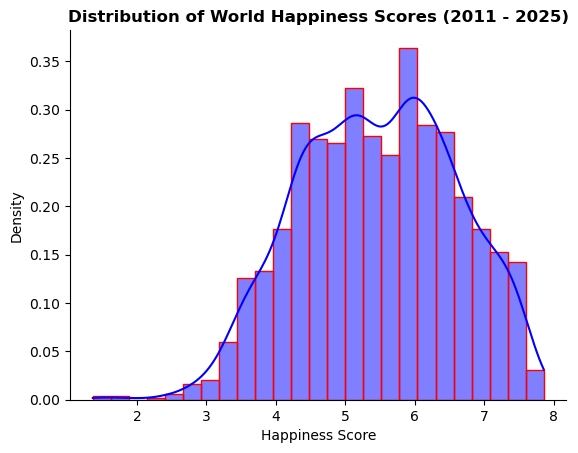

In [60]:
## creating a distribution of World Happiness Scores from 2011 to 2025

import seaborn as sns

sns.histplot(x = WorldHappinessCopy['happiness_score'], kde = True, color = "blue", edgecolor = "red", stat = "density")
plt.title('Distribution of World Happiness Scores (2011 - 2025)', fontweight = 'bold')
plt.xlabel('Happiness Score')
plt.ylabel('Density')
sns.despine()
plt.show()

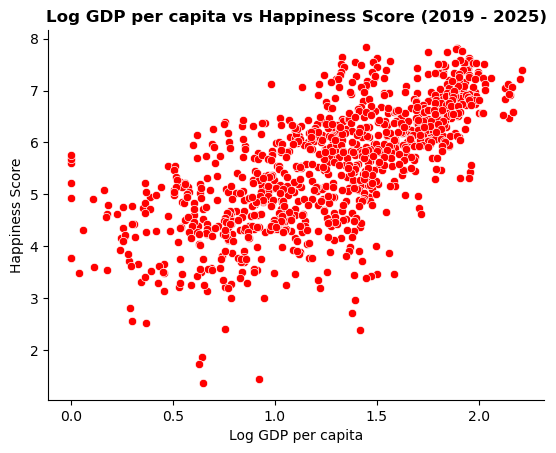

In [74]:
## UNUSED: creating scatter plot without regression line to see the difference with and without.

sns.scatterplot(data = WorldHappinessLast1021, x = "explained_log_gdp_per_capita", y = "happiness_score", color = "red")
plt.title('Log GDP per capita vs Happiness Score (2019 - 2025)', fontweight = 'bold')
plt.xlabel('Log GDP per capita')
plt.ylabel('Happiness Score')
sns.despine()
plt.show()

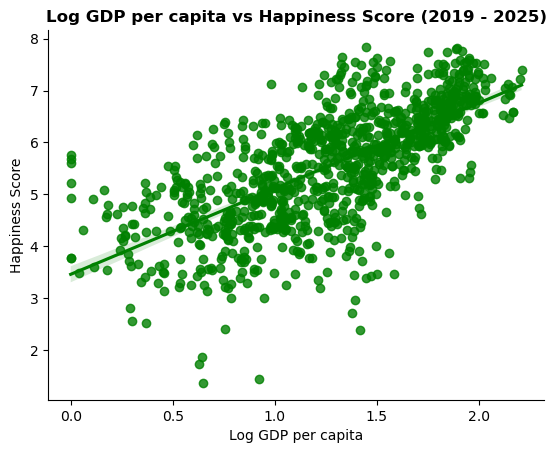

In [84]:
## created a scatter plot with a regression line to showcase the relationship between explained_log_gdp_per_capita and happiness_score

sns.regplot(data = WorldHappinessLast1021, x = "explained_log_gdp_per_capita", y = "happiness_score", color = "green")
plt.title('Log GDP per capita vs Happiness Score (2019 - 2025)', fontweight = 'bold')
plt.xlabel('Log GDP per capita')
plt.ylabel('Happiness Score')
sns.despine()
plt.show()

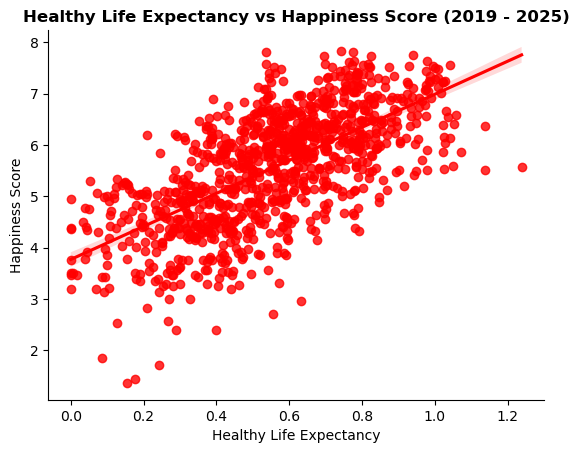

In [88]:
## created a scatter plot with a regression line to showcase the relationship between explained_healthy_life_expectancy and happiness_score

sns.regplot(data = WorldHappinessLast1021, x = "explained_healthy_life_expectancy", y = "happiness_score", color = "red")
plt.title('Healthy Life Expectancy vs Happiness Score (2019 - 2025)', fontweight = 'bold')
plt.xlabel('Healthy Life Expectancy')
plt.ylabel('Happiness Score')
sns.despine()
plt.show()

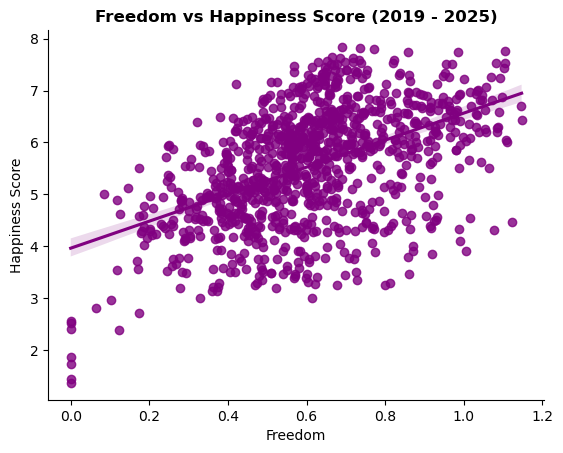

In [90]:
## created a scatter plot with a regression line to showcase the relationship between explained_freedom and happiness_score

sns.regplot(data = WorldHappinessLast1021, x = "explained_freedom", y = "happiness_score", color = "purple")
plt.title('Freedom vs Happiness Score (2019 - 2025)', fontweight = 'bold')
plt.xlabel('Freedom')
plt.ylabel('Happiness Score')
sns.despine()
plt.show()

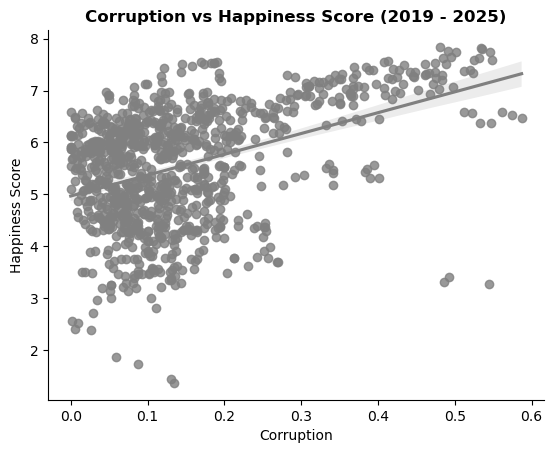

In [96]:
## created a scatter plot with a regression line to showcase the relationship between explained_corruption and happiness_score

sns.regplot(data = WorldHappinessLast1021, x = "explained_corruption", y = "happiness_score", color = "gray")
plt.title('Corruption vs Happiness Score (2019 - 2025)', fontweight = 'bold')
plt.xlabel('Corruption')
plt.ylabel('Happiness Score')
sns.despine()
plt.show()

In [108]:
## calling this dataframe for easier access

WorldHappinessLast1021

,year,rank_in_year,country,happiness_score,lower_whisker,upper_whisker,explained_log_gdp_per_capita,explained_social_support,explained_healthy_life_expectancy,explained_freedom,explained_generosity,explained_corruption,dystopia_plus_residual
1095,2019,2,Denmark,7.6456,7.579955,7.711245,1.326949,1.503449,0.979333,0.665040,0.242793,0.495260,2.432741
1096,2019,3,Switzerland,7.5599,7.491272,7.628528,1.390774,1.472403,1.040533,0.628954,0.269056,0.407946,2.350267
1097,2019,4,Iceland,7.5045,7.387653,7.621347,1.326502,1.547567,1.000843,0.661981,0.362330,0.144541,2.460688
1098,2019,5,Norway,7.4880,7.419719,7.556281,1.424207,1.495173,1.008072,0.670201,0.287985,0.434101,2.168266
1099,2019,6,Netherlands,7.4489,7.394428,7.503372,1.338946,1.463646,0.975675,0.613626,0.336318,0.368570,2.352117
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2111,2025,143,Botswana,3.4640,3.335000,3.593000,1.582000,0.989000,0.017000,0.860000,0.022000,0.093000,-0.099000
2112,2025,144,Zimbabwe,3.3460,3.244000,3.449000,1.213000,0.782000,0.189000,0.729000,0.056000,0.128000,0.251000
2113,2025,145,Malawi,3.2840,3.153000,3.415000,0.864000,0.326000,0.299000,0.812000,0.109000,0.143000,0.730000
2114,2025,146,Sierra Leone,3.2510,3.147000,3.355000,1.054000,0.692000,0.405000,0.800000,0.131000,0.052000,0.117000


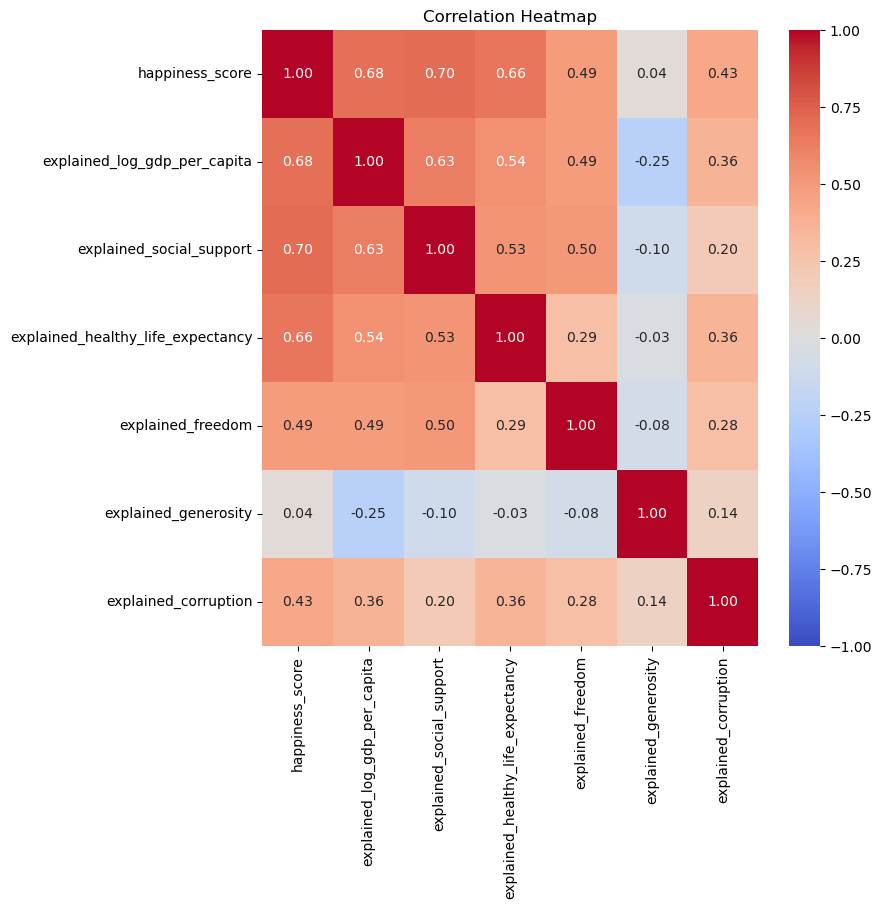

In [116]:
## created a correlation heatmap to display the correlation of each variable with another

plt.figure(figsize=(8,8))
chosen_columns = ['happiness_score', 'explained_log_gdp_per_capita', 'explained_social_support', 'explained_healthy_life_expectancy', 'explained_freedom', 'explained_generosity', 'explained_corruption']
correlation_matrix = WorldHappinessCopy[chosen_columns].corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', fmt=".2f", vmin = -1, vmax = 1)
plt.title('Correlation Heatmap')
plt.show()

In [139]:
## attempted to run a hypothesis test where H0: There is no linear correlation between happiness scores and log gdp per capita but

from scipy.stats import pearsonr
corr, pvalue = pearsonr(WorldHappinessLast1021['explained_log_gdp_per_capita'], WorldHappinessLast1021['happiness_score'])

print('Correlation coefficient:', corr)
print('p-value:', pvalue)

KeyError: 'explaianed_log_gdp_per_capita'